In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
df = pd.read_csv("Position_Salaries.csv")

print("First Five Records")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

# Input Feature
X = df[["Level"]]

# Target Variable
y = df["Salary"]

print("\nInput Feature:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("Salary")


First Five Records
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes
None

Summary Statistics
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000

Input Feature:
['Level']

Target Variable:
Salary


In [9]:
print("\nMissing Values")
print(df.isnull().sum())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Missing Values
Position    0
Level       0
Salary      0
dtype: int64

Training Shape: (8, 1)
Testing Shape: (2, 1)


In [10]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train Model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predictions
y_pred = model.predict(X_test_poly)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n========== Evaluation ==========")
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("R2 Score :", round(r2,4))


========== Evaluation ==========
MAE : 70635.25
MSE : 6263853282.86
R2 Score : 0.8763


/tmp/ipykernel_655/3264886507.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


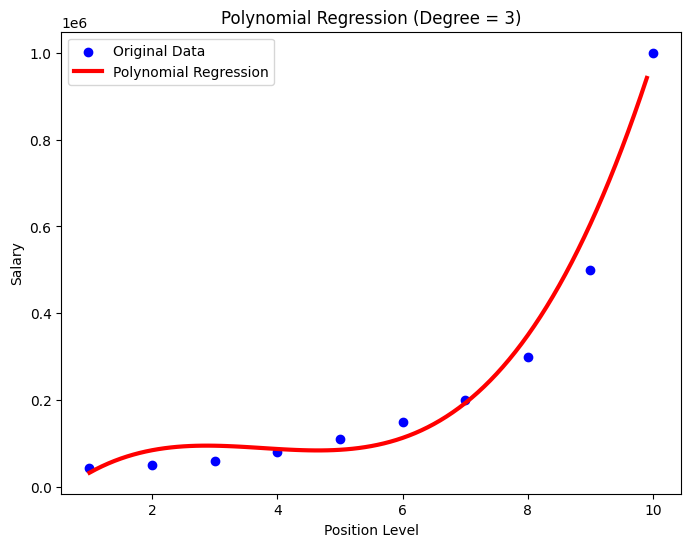

In [12]:
X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(-1,1)

plt.figure(figsize=(8,6))

plt.scatter(X, y, color='blue', label='Original Data')

plt.plot(
    X_grid,
    model.predict(poly.transform(X_grid)),
    color='red',
    linewidth=3,
    label='Polynomial Regression'
)

plt.title("Polynomial Regression (Degree = 3)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()

plt.show()

In [13]:
print("\nObservations")
print("1. Polynomial Regression captures the curved relationship between position level and salary.")
print("2. The model fits the data much better than a simple Linear Regression model.")
print("3. Salary increases rapidly at higher position levels, which Polynomial Regression models effectively.")


Observations
1. Polynomial Regression captures the curved relationship between position level and salary.
2. The model fits the data much better than a simple Linear Regression model.
3. Salary increases rapidly at higher position levels, which Polynomial Regression models effectively.


In [14]:
print("""
Conclusion

Polynomial Regression successfully modeled the non-linear
relationship between employee position level and salary.
Unlike Linear Regression, which fits only a straight line,
Polynomial Regression fits a curved relationship by adding
higher-degree features. This results in more accurate salary
predictions when the relationship between variables is
non-linear. The model achieved good performance based on
MAE, MSE, and R² score. One major advantage of Polynomial
Regression for this dataset is its ability to capture the
rapid increase in salary at higher position levels, making
it more suitable than Linear Regression for this problem.
""")


Conclusion

Polynomial Regression successfully modeled the non-linear
relationship between employee position level and salary.
Unlike Linear Regression, which fits only a straight line,
Polynomial Regression fits a curved relationship by adding
higher-degree features. This results in more accurate salary
predictions when the relationship between variables is
non-linear. The model achieved good performance based on
MAE, MSE, and R² score. One major advantage of Polynomial
Regression for this dataset is its ability to capture the
rapid increase in salary at higher position levels, making
it more suitable than Linear Regression for this problem.

